# 📘 Importing

In [26]:
import os
import ast
import operator
import pynvml

import pandas as pd

from dotenv import load_dotenv
from operator import itemgetter
from codecarbon import track_emissions
from IPython.display import Image, display

from time import sleep

In [3]:
from pydantic import BaseModel, Field
from typing_extensions import TypedDict, List, Literal, Annotated

In [4]:
from langgraph.graph import StateGraph, START, END

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_ollama import ChatOllama, OllamaEmbeddings

from langchain_core.messages import HumanMessage, SystemMessage, BaseMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

from langgraph.prebuilt import create_react_agent, ToolNode
from langgraph_supervisor import create_supervisor

from langchain.tools.retriever import create_retriever_tool

from langchain_core.tools import tool, Tool

from langchain_core.output_parsers import StrOutputParser

from langchain.vectorstores import FAISS
from langchain.schema import Document

In [24]:
from deepeval import evaluate
from deepeval.dataset import EvaluationDataset
from deepeval.metrics import (
    AnswerRelevancyMetric, 
    FaithfulnessMetric,
    ContextualRelevancyMetric,
    ContextualPrecisionMetric,
    ContextualRecallMetric
)
from deepeval.test_case import LLMTestCase
from deepeval.models import OllamaModel

# ⚙️ Settings

In [5]:
class State(TypedDict):
    input: str
    output: str

In [25]:
# llm = ChatOpenAI(model="gpt-4o", temperature=0)
llm = ChatOllama(model="gpt-oss:latest")

llm_eval = OllamaModel(model="gemma3:27b")

In [27]:
answer_relevancy = AnswerRelevancyMetric(threshold=0.5, model=llm_eval)
faithfulness = FaithfulnessMetric(threshold=0.5, model=llm_eval)
contextual_relevancy = ContextualRelevancyMetric(threshold=0.5, model=llm_eval)
contextual_precision = ContextualPrecisionMetric(threshold=0.5, model=llm_eval)
contextual_recall = ContextualRecallMetric(threshold=0.5, model=llm_eval)

In [7]:
def llm_answer(state: State):
    prompt_template = ChatPromptTemplate.from_messages([
        (
            "system", 
            "You are an expert agent in industrial communication networks, with profound "
            "and extensive knowledge of the PROFIBUS protocol. Your role is to answer "
            "technical questions accurately and in detail, as a senior engineer would."
        ),
        (
            "human", 
            "{input}"
        )
    ])
    
    chain = (
        prompt_template
        | llm
        | StrOutputParser()
    )

    response = chain.invoke({
        "input": state["input"]
    })

    return {"output": response}


In [8]:
workflow = StateGraph(State)

workflow.add_node("llm", llm_answer)

workflow.add_edge(START, "llm")
workflow.add_edge("llm", END)

workflow = workflow.compile()

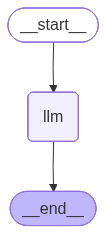

In [9]:
display(Image(workflow.get_graph().draw_mermaid_png()))

# 📊 Evaluation

In [16]:
import time
from codecarbon import EmissionsTracker

In [17]:
qna_dev = pd.read_csv("../../data/QnA_dev.csv")
qna_eng = pd.read_csv("../../data/QnA_eng.csv")

In [18]:
qna_dev["response"] = ""
qna_dev["duration"] = 0.0
qna_dev["emission_kg"] = 0.0

tracker = EmissionsTracker(project_name="00_QnA_dev")

tracker.start()

for i, row in qna_dev.iterrows():
    tracker.start_task(f"Question id: {row['id']}")
    start_time = time.perf_counter()

    response = workflow.invoke({
        "input": row["question"]
    })

    end_time = time.perf_counter()
    emissions_data = tracker.stop_task()

    duration = end_time - start_time

    response = response["output"]

    qna_dev.at[i, "response"] = response
    qna_dev.at[i, "duration"] = duration
    qna_dev.at[i, "emission_kg"] = emissions_data.emissions

[codecarbon WARNING @ 17:11:19] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 17:11:19] [setup] RAM Tracking...
[codecarbon INFO @ 17:11:19] [setup] CPU Tracking...
[codecarbon WARNING @ 17:11:21] We saw that you have a Intel(R) Core(TM) i9-14900K but we don't know it. Please contact us.
[codecarbon WARNING @ 17:11:21] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 17:11:21] CPU Model on constant consumption mode: Intel(R) Core(TM) i9-14900K
[codecarbon WARNING @ 17:11:21] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 17:11:21] [setup] GPU Tracking...
[codecarbon INFO @ 17:11:21] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 17:11:21] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global

In [22]:
qna_dev.to_csv("../../data/00_QnA_dev.csv")

In [20]:
qna_eng["response"] = ""
qna_eng["duration"] = 0.0
qna_eng["emission_kg"] = 0.0

tracker = EmissionsTracker(project_name="00_QnA_eng")

tracker.start()

for i, row in qna_eng.iterrows():
    tracker.start_task(f"Question id: {row['id']}")
    start_time = time.perf_counter()

    response = workflow.invoke({
        "input": row["question"]
    })

    end_time = time.perf_counter()
    emissions_data = tracker.stop_task()

    duration = end_time - start_time

    response = response["output"]

    qna_eng.at[i, "response"] = response
    qna_eng.at[i, "duration"] = duration
    qna_eng.at[i, "emission_kg"] = emissions_data.emissions

[codecarbon WARNING @ 18:01:17] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 18:01:17] [setup] RAM Tracking...
[codecarbon INFO @ 18:01:17] [setup] CPU Tracking...
[codecarbon WARNING @ 18:01:19] We saw that you have a Intel(R) Core(TM) i9-14900K but we don't know it. Please contact us.
[codecarbon WARNING @ 18:01:19] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 18:01:19] CPU Model on constant consumption mode: Intel(R) Core(TM) i9-14900K
[codecarbon WARNING @ 18:01:19] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 18:01:19] [setup] GPU Tracking...
[codecarbon INFO @ 18:01:19] Tracking Nvidia GPU via pynvml
[codecarbon INFO @ 18:01:19] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: global

In [23]:
qna_eng.to_csv("../../data/00_QnA_eng.csv")